In [113]:
import pickle
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (recall_score, f1_score, roc_auc_score, 
                             precision_recall_curve, auc, confusion_matrix, 
                             classification_report, roc_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Chargement des données de preprocessing

In [114]:
with open('../data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (16538, 10), X_test: (4135, 10)
y_train: (16538,), y_test: (4135,)


# 2. Entraînement du modèle de LogisticRegression

In [115]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# 3. Entraînement RandomForest

In [116]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# 4. Entraînement GradientBoosting

In [117]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

# 5. Entraînement du modèle Deep Learning

Calcul du poids des classes

In [118]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.5872869318181818, 1: 3.3641171684296176}


Construction du modèle, compiler et early stopping

In [119]:
mlp = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                 kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
mlp.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)


/Users/tristanretali/Documents/M1/projet-data-science/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Entraînement

In [120]:
history = mlp.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8255 - loss: 0.4273 - val_accuracy: 0.8903 - val_loss: 0.3402
Epoch 2/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8872 - loss: 0.3134 - val_accuracy: 0.9060 - val_loss: 0.2834
Epoch 3/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9002 - loss: 0.2971 - val_accuracy: 0.8963 - val_loss: 0.2977
Epoch 4/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8974 - loss: 0.2926 - val_accuracy: 0.9060 - val_loss: 0.2766
Epoch 5/5
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9000 - loss: 0.2865 - val_accuracy: 0.9129 - val_loss: 0.2622
Restoring model weights from the end of the best epoch: 5.


Prédictions

In [ ]:
y_pred_proba_mlp = mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp = (y_pred_proba_mlp >= 0.5).astype(int)


y_pred_mlp shape: (4135,), y_pred_proba_mlp shape: (4135,)


Visualisation courbe d'apprentissage

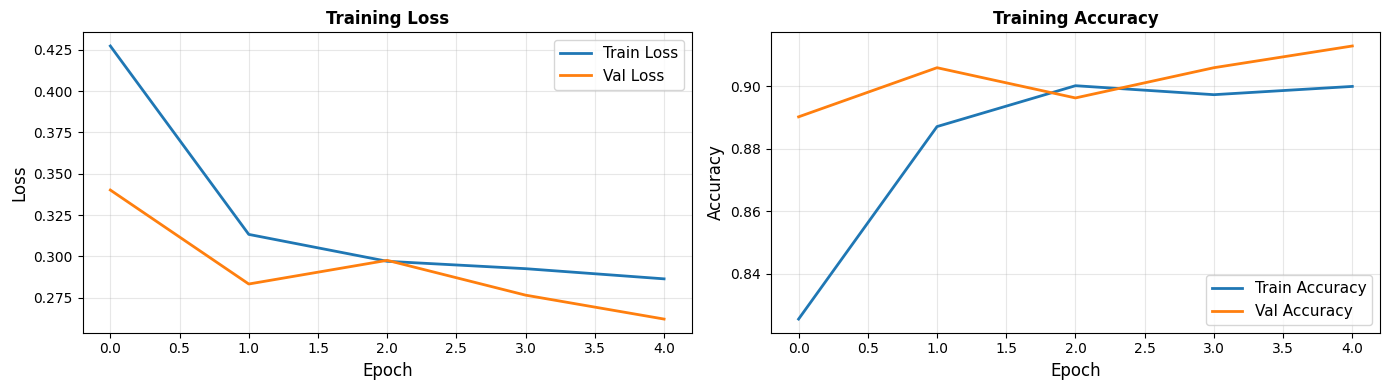

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Fonction d'évaluation

In [123]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Évalue un modèle avec recall, F1, ROC-AUC, PR-AUC"""
    
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    # PR-AUC
    precision, recall_curve_vals, thresholds = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_curve_vals, precision)
    
    print(f"\n{model_name}:")
    print(f"  Recall:   {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  PR-AUC:   {pr_auc:.4f}")
    
    return {
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

Évaluation des trois modèles

In [124]:
results_lr = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression")
results_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest")
results_gb = evaluate_model(y_test, y_pred_gb, y_pred_proba_gb, "Gradient Boosting")
results_mlp = evaluate_model(y_test, y_pred_mlp, y_pred_proba_mlp, "Deep Learning")


Logistic Regression:
  Recall:   0.8860
  F1-Score: 0.7391
  ROC-AUC:  0.9584
  PR-AUC:   0.8422

Random Forest:
  Recall:   0.9202
  F1-Score: 0.8905
  ROC-AUC:  0.9937
  PR-AUC:   0.9659

Gradient Boosting:
  Recall:   0.8681
  F1-Score: 0.8803
  ROC-AUC:  0.9918
  PR-AUC:   0.9524

Deep Learning:
  Recall:   0.8876
  F1-Score: 0.7405
  ROC-AUC:  0.9563
  PR-AUC:   0.8424


# 6. Comparaison des modèles

In [125]:
comparison = pd.DataFrame({
    'Logistic Regression': results_lr,
    'Random Forest': results_rf,
    'Gradient Boosting': results_gb,
    'Deep Learning': results_mlp
}).T

comparison_metrics = comparison[['recall', 'f1', 'roc_auc', 'pr_auc']]

print("Résumé comparatif :")
print(comparison_metrics.round(4))


print("\nMeilleur modèle par métrique:")
for metric in ['recall', 'f1', 'roc_auc', 'pr_auc']:
    best = comparison_metrics[metric].idxmax()
    score = comparison_metrics[metric].max()
    print(f"  {metric.upper():8} → {best:25} ({score:.4f})")

Résumé comparatif :
                       recall        f1   roc_auc    pr_auc
Logistic Regression  0.885993   0.73913  0.958414  0.842173
Random Forest        0.920195  0.890465  0.993733  0.965903
Gradient Boosting    0.868078  0.880264  0.991783  0.952438
Deep Learning        0.887622  0.740489  0.956326  0.842395

Meilleur modèle par métrique:
  RECALL   → Random Forest             (0.9202)
  F1       → Random Forest             (0.8905)
  ROC_AUC  → Random Forest             (0.9937)
  PR_AUC   → Random Forest             (0.9659)


# 7. Visualisation ROC Curves

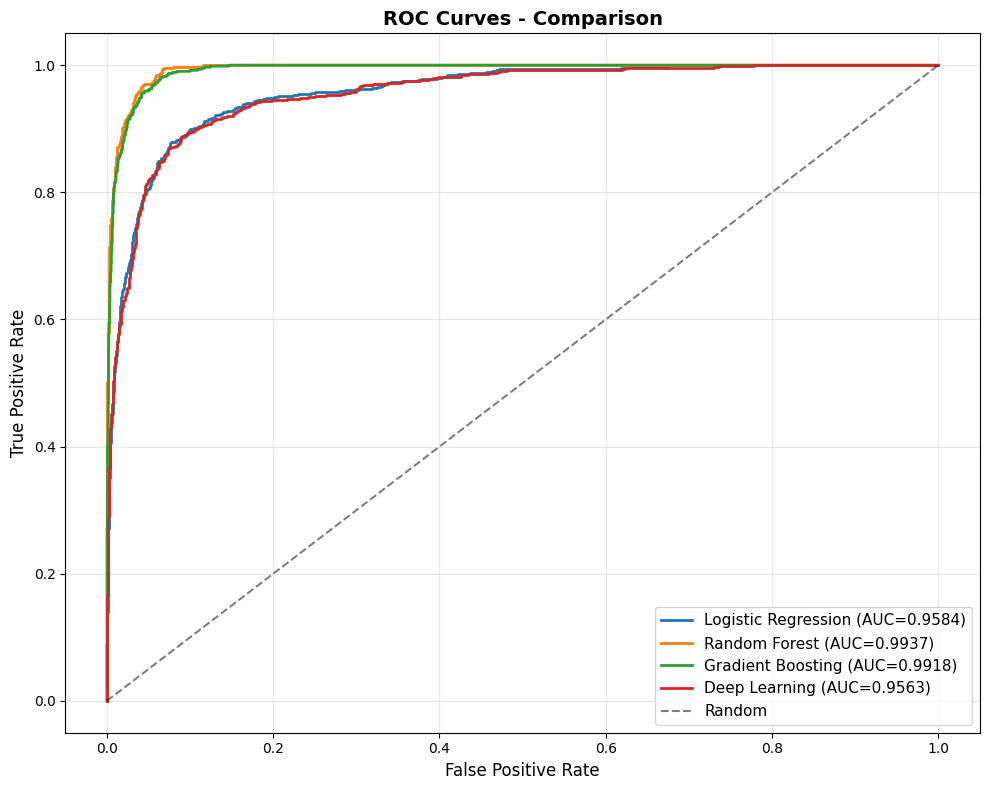

In [126]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# ROC curves
for name, pred_proba, results in [
    ('Logistic Regression', y_pred_proba_lr, results_lr),
    ('Random Forest', y_pred_proba_rf, results_rf),
    ('Gradient Boosting', y_pred_proba_gb, results_gb),
    ('Deep Learning', y_pred_proba_mlp, results_mlp)
]:
    fpr, tpr, _ = roc_curve(y_test, pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={results["roc_auc"]:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Visualisation - PR Curves

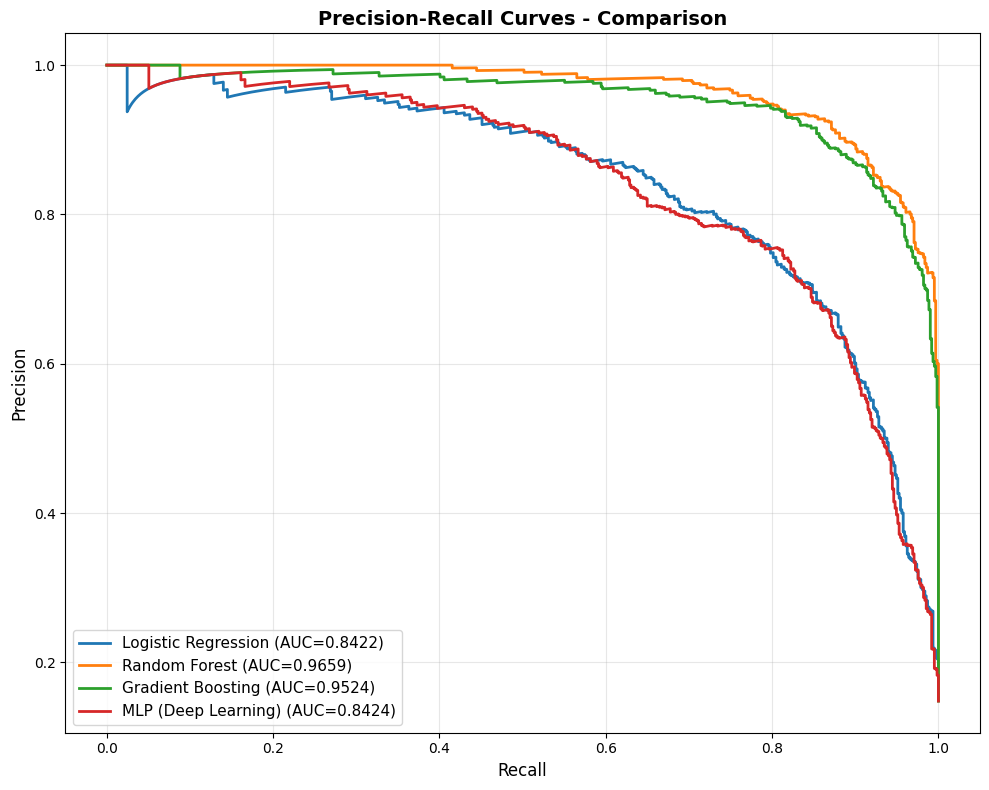

In [127]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for name, pred_proba, results in [
    ('Logistic Regression', y_pred_proba_lr, results_lr),
    ('Random Forest', y_pred_proba_rf, results_rf),
    ('Gradient Boosting', y_pred_proba_gb, results_gb),
    ('MLP (Deep Learning)', y_pred_proba_mlp, results_mlp)
]:
    precision, recall_vals, _ = precision_recall_curve(y_test, pred_proba)
    pr_auc = auc(recall_vals, precision)
    ax.plot(recall_vals, precision, label=f'{name} (AUC={pr_auc:.4f})', linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Matrice de confusion

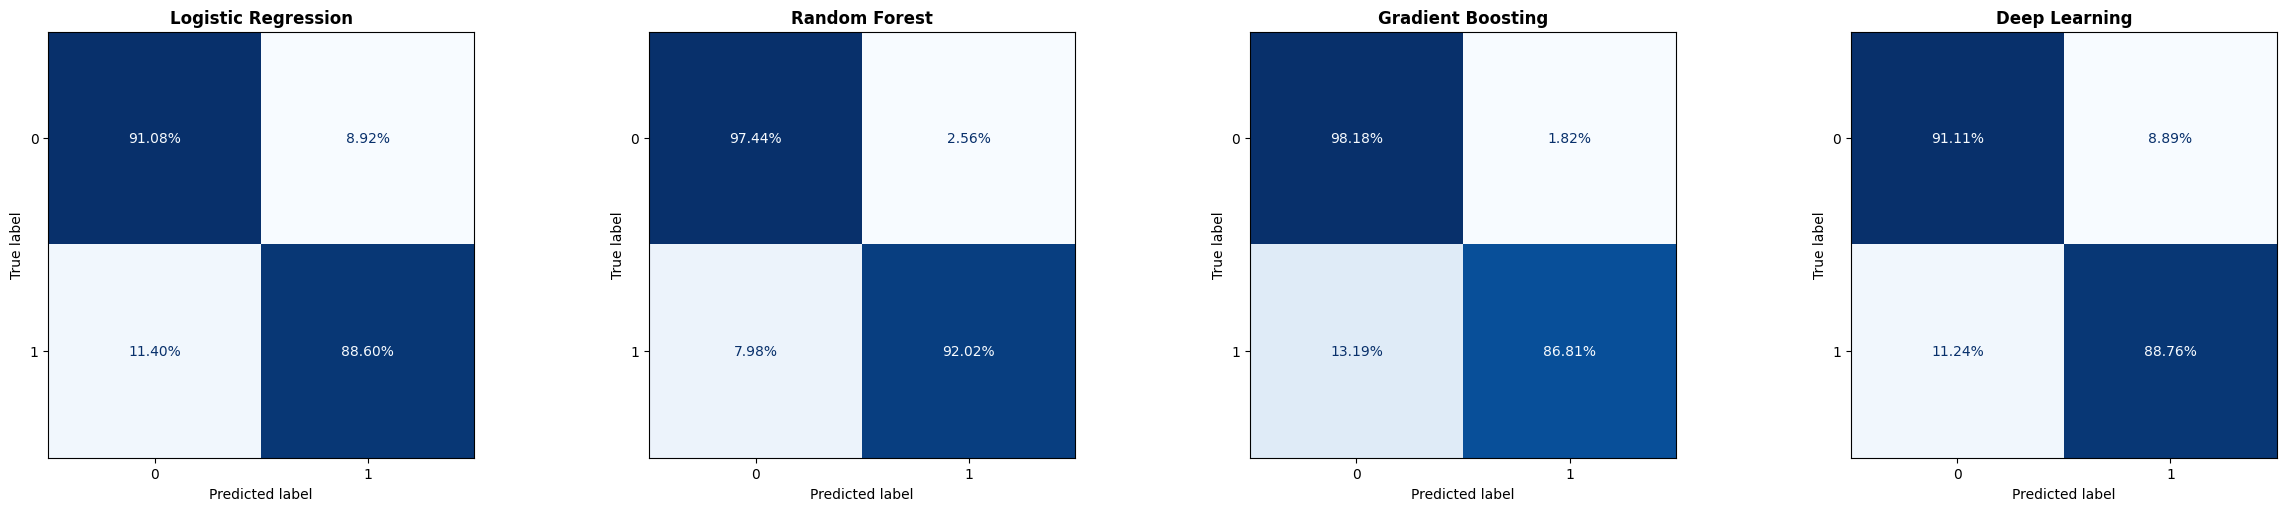

In [135]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

for idx, (name, y_pred) in enumerate([
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb),
    ('Deep Learning', y_pred_mlp)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        normalize='true',
        # display_labels=['No Failure', 'Failure'],
        cmap='Blues',
        values_format='.2%',
        ax=axes[idx],
        colorbar=False
    )
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

plt.show()

# 10. Rapport de performance

In [129]:
best_model_name = comparison_metrics['recall'].idxmax()

if best_model_name == 'Logistic Regression':
    y_pred_best = y_pred_lr
elif best_model_name == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model_name == 'Gradient Boosting':
    y_pred_best = y_pred_gb
else:
    y_pred_best = y_pred_mlp

print(f"Meilleur modèle (par Recall): {best_model_name}")
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Failure', 'Failure']))

Meilleur modèle (par Recall): Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      3521
     Failure       0.86      0.92      0.89       614

    accuracy                           0.97      4135
   macro avg       0.92      0.95      0.94      4135
weighted avg       0.97      0.97      0.97      4135



# 11. SHAP sur le modèle le plus performant

In [130]:
with open('../data/preprocessor.pkl','rb') as f:
    pre = pickle.load(f)

In [131]:
def get_feature_names(pre):
    names = []
    for name, trans, cols in pre.transformers_:
        if hasattr(trans, 'named_steps'):
            last = trans.named_steps[list(trans.named_steps.keys())[-1]]
            fn = last.get_feature_names_out(cols) if hasattr(last,'get_feature_names_out') else cols
        else:
            fn = trans.get_feature_names_out(cols) if hasattr(trans,'get_feature_names_out') else cols
        if hasattr(fn, 'tolist'):
            fn = fn.tolist()
        names.extend(list(fn))
    return names

feature_names = get_feature_names(pre)

X_test_df = pd.DataFrame(X_test, columns=feature_names)

In [132]:
feature_importance_rf = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [133]:
feature_importance_rf

temperature_motor           0.263204
rpm                         0.240940
vibration_rms               0.176941
current_phase_avg           0.169584
pressure_level              0.092486
ambient_temp                0.017334
machine_type_Pump           0.011340
machine_type_Robotic Arm    0.009754
machine_type_Compressor     0.009350
machine_type_CNC            0.009066
dtype: float64

# 11. Sauvegarde des modèles

In [134]:
mlp.save('../models/mlp_model.h5')

with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/gradient_boosting.pkl', 'wb') as f:
    pickle.dump(gb, f)

with open('../models/results.pkl', 'wb') as f:
    pickle.dump({
        'comparison': comparison_metrics,
        'threshold': 0.5,
        'results': {
            'lr': results_lr,
            'rf': results_rf,
            'gb': results_gb,
            'mlp': results_mlp
        },
        'best_model': comparison_metrics['recall'].idxmax(),
        'history': history,
        'feature_names': feature_names,
        'feature_importance': feature_importance_rf
    }, f)